# 02 · Modelo de detección de fraude (P2 y P3)

**Objetivo:** mostrar e interpretar los resultados del modelo entrenado por el pipeline.

**Requisito:** haber corrido el pipeline completo: `python -m src.pipeline`
(o solo `--etapas gold_features modelo` si Silver ya existe). Este notebook **no** vuelve a entrenar: lee los resultados guardados.

In [10]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))  # para importar src/ desde notebooks/

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pyspark.sql import functions as F

from src.config import SILVER, GOLD, META, TABLE_FORMAT, get_spark, ruta
from src.graficos import estilo, guardar, etiquetar_barras, LEGITIMA, FRAUDE, MODELO_2, REFERENCIA, TEXTO_2

estilo()
spark = get_spark("notebook")
print("Spark", spark.version)

Spark 3.5.8


In [11]:
m = json.loads((META / "modelo_metricas.json").read_text(encoding="utf-8"))
curva = spark.read.format(TABLE_FORMAT).load(ruta(GOLD, "curva_costo_umbral")).toPandas().sort_values("umbral")
print(f"Peso de cada fraude en el entrenamiento (class weight): {m['peso_clase_fraude']}")
print(f"Filas de entrenamiento: {m['filas_entrenamiento']}")

Peso de cada fraude en el entrenamiento (class weight): 27.59
Filas de entrenamiento: {'1': 17669, '0': 487441}


## 1. P2 · ¿Qué tan bien predecimos el fraude?

Validación por tiempo: el modelo se entrenó con los primeros días y se evalúa con los **últimos 30**, que nunca vio.
Métricas con umbral 0,5. **No se usa accuracy.**

In [12]:
filas = {"GBT (class weights)": m["gbt"]}
if "regresion_logistica" in m:
    filas["Regresión Logística (base)"] = m["regresion_logistica"]
tabla = pd.DataFrame(filas).T[["roc_auc", "pr_auc", "recall", "precision", "f1"]]
tabla.columns = ["ROC-AUC", "PR-AUC", "Recall", "Precision", "F1"]
display(tabla.round(3))

c = m["criterio_p2"]
print(f"Meta de la Fase 1: {c['meta']}  ->  {'CUMPLE' if c['cumple'] else 'NO CUMPLE'}")

,ROC-AUC,PR-AUC,Recall,Precision,F1
GBT (class weights),0.897,0.484,0.756,0.182,0.294
Regresión Logística (base),0.810,0.127,0.720,0.101,0.177


Meta de la Fase 1: ROC-AUC >= 0.85 y Recall >= 0.70 (umbral 0.5)  ->  CUMPLE


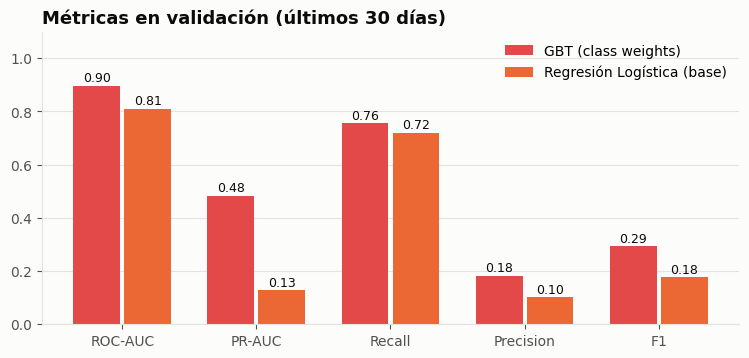

In [13]:
fig, ax = plt.subplots(figsize=(9, 3.8))
x = np.arange(len(tabla.columns))
ancho = 0.38
colores = [FRAUDE, MODELO_2]
for i, (nombre, fila) in enumerate(tabla.iterrows()):
    barras = ax.bar(x + (i - (len(tabla) - 1) / 2) * ancho, fila.values, ancho * 0.92, color=colores[i], label=nombre)
    etiquetar_barras(ax, barras, "{:.2f}")
ax.set_xticks(x, tabla.columns)
ax.set_ylim(0, 1.1)
ax.set_title("Métricas en validación (últimos 30 días)")
ax.legend(loc="upper right")
guardar(fig, "02_metricas_modelos")
plt.show()

## 2. ¿Qué variables pesan más?

Importancia de variables del GBT: cuánto contribuye cada una a las decisiones del modelo.

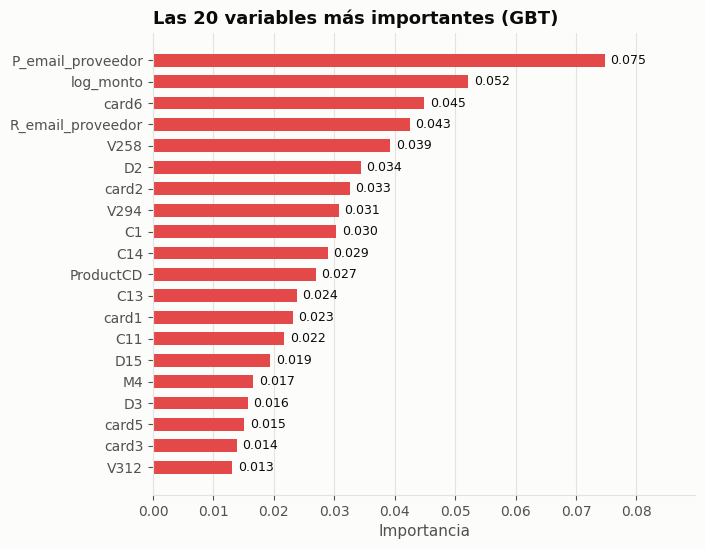

In [14]:
imp = pd.DataFrame(m["importancia_variables_top20"])[::-1]
fig, ax = plt.subplots(figsize=(7, 6))
barras = ax.barh(imp.variable, imp.importancia, color=FRAUDE, height=0.6)
etiquetar_barras(ax, barras, "{:.3f}", horizontal=True)
ax.set_title("Las 20 variables más importantes (GBT)")
ax.set_xlabel("Importancia")
ax.set_xlim(0, imp.importancia.max() * 1.2)
ax.grid(axis="x"); ax.grid(axis="y", visible=False)
guardar(fig, "02_importancia_variables")
plt.show()

## 3. P3 · ¿Qué umbral minimiza el costo?

Costo total = alertas revisadas × costo de revisión + fraudes no detectados × (monto + contracargo).
Los costos son **supuestos** (en `.env`) y quedan pendientes de validar con el profesor.

Supuestos: revisión 5.0 USD por alerta · contracargo 25.0 USD por fraude no detectado
Umbral óptimo: 0.40  ·  costo 183,649 USD frente a 532,286 USD sin modelo
Ahorro: 348,637 USD en 30 días  ·  Recall 0.82  ·  585 alertas por día para revisar


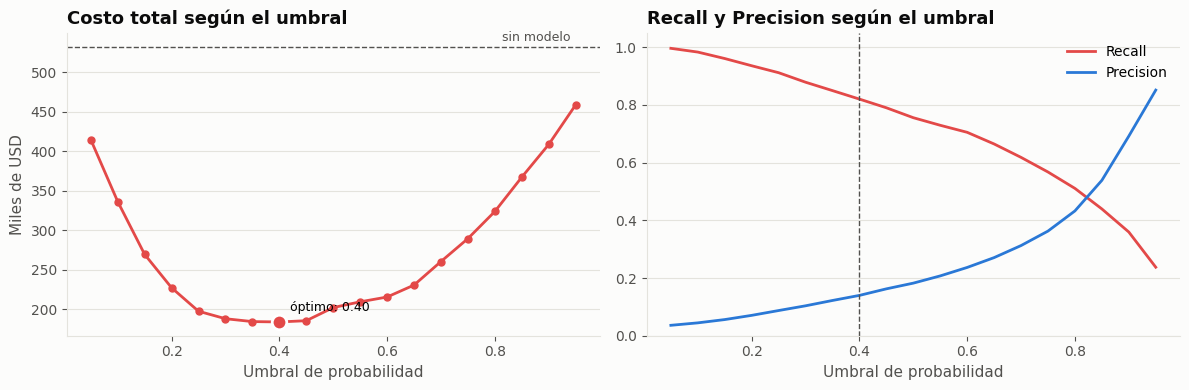

In [15]:
p3 = m["p3_umbral_optimo"]
costos = m["costos_supuestos"]
print(f"Supuestos: revisión {costos['revision_usd']} USD por alerta · contracargo {costos['contracargo_usd']} USD por fraude no detectado")
print(f"Umbral óptimo: {p3['umbral']:.2f}  ·  costo {p3['costo_total_usd']:,.0f} USD frente a {p3['costo_sin_modelo_usd']:,.0f} USD sin modelo")
print(f"Ahorro: {p3['ahorro_usd']:,.0f} USD en {p3['periodo_validacion_dias']} días  ·  Recall {p3['recall']:.2f}  ·  {p3['alertas_por_dia']:.0f} alertas por día para revisar")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(curva.umbral, curva.costo_total_usd / 1000, color=FRAUDE, marker="o", markersize=5)
axes[0].axhline(p3["costo_sin_modelo_usd"] / 1000, color=REFERENCIA, linestyle="--", linewidth=1)
axes[0].annotate("sin modelo", (curva.umbral.max(), p3["costo_sin_modelo_usd"] / 1000), xytext=(-4, 4),
                 textcoords="offset points", ha="right", fontsize=9, color=TEXTO_2)
axes[0].scatter([p3["umbral"]], [p3["costo_total_usd"] / 1000], s=110, color=FRAUDE, edgecolor="white", linewidth=2, zorder=3)
axes[0].annotate(f"óptimo: {p3['umbral']:.2f}", (p3["umbral"], p3["costo_total_usd"] / 1000), xytext=(8, 8),
                 textcoords="offset points", fontsize=9)
axes[0].set_title("Costo total según el umbral")
axes[0].set_xlabel("Umbral de probabilidad"); axes[0].set_ylabel("Miles de USD")

axes[1].plot(curva.umbral, curva.recall, color=FRAUDE, label="Recall")
axes[1].plot(curva.umbral, curva.precision, color=LEGITIMA, label="Precision")
axes[1].axvline(p3["umbral"], color=REFERENCIA, linestyle="--", linewidth=1)
axes[1].set_title("Recall y Precision según el umbral")
axes[1].set_xlabel("Umbral de probabilidad"); axes[1].set_ylim(0, 1.05)
axes[1].legend()
fig.tight_layout()
guardar(fig, "02_costo_umbral")
plt.show()

## 4. Matriz de confusión con el umbral óptimo

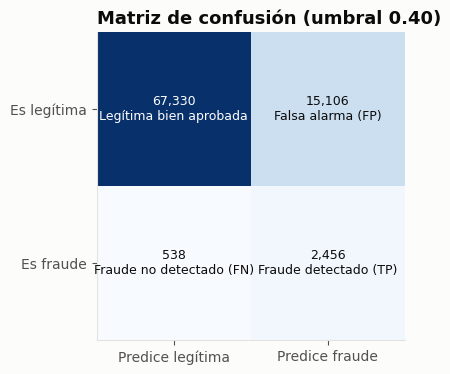

In [16]:
fila = curva.set_index("umbral").loc[p3["umbral"]]
matriz = np.array([[fila.tn, fila.fp], [fila.fn, fila.tp]])
fig, ax = plt.subplots(figsize=(5, 4))
ax.imshow(matriz, cmap="Blues")
etiquetas = [["Legítima bien aprobada", "Falsa alarma (FP)"], ["Fraude no detectado (FN)", "Fraude detectado (TP)"]]
for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{matriz[i, j]:,.0f}\n{etiquetas[i][j]}", ha="center", va="center", fontsize=9,
                color="white" if matriz[i, j] > matriz.max() / 2 else "#0b0b0b")
ax.set_xticks([0, 1], ["Predice legítima", "Predice fraude"]); ax.set_yticks([0, 1], ["Es legítima", "Es fraude"])
ax.grid(False)
ax.set_title(f"Matriz de confusión (umbral {p3['umbral']:.2f})")
guardar(fig, "02_matriz_confusion")
plt.show()

## 5. Registro en MLflow

In [17]:
import os
os.environ.setdefault("MLFLOW_ALLOW_FILE_STORE", "true")
import mlflow
from src.config import LAKEHOUSE

mlflow.set_tracking_uri((LAKEHOUSE / "mlruns").resolve().as_uri())
runs = mlflow.search_runs(experiment_names=["fraude-ieee-cis"])
cols = [c for c in ["run_id", "tags.mlflow.runName", "start_time", "metrics.gbt_roc_auc", "metrics.gbt_recall",
                    "metrics.gbt_pr_auc", "metrics.p3_ahorro_usd"] if c in runs.columns]
runs[cols]

,run_id,tags.mlflow.runName,start_time,metrics.gbt_roc_auc,metrics.gbt_recall,metrics.gbt_pr_auc,metrics.p3_ahorro_usd
0,5906bc5516f14d2497c7df51d0f96c39,gbt_60it_100pct,2026-10-04 03:54:50.498000+00:00,0.8974,0.7558,0.4841,348636.70
1,f91e551a07064f06a0f32931fd174874,gbt_30it_20pct,2026-10-04 03:24:25.044000+00:00,0.8862,0.7488,0.4614,332023.68


### Interpretación del equipo

**P2: sí podemos detectar el fraude con la calidad pedida.** Evaluado con los últimos 30 días, que el modelo nunca vio (85.430 transacciones), el GBT con class weights obtiene ROC-AUC 0,897 y Recall 0,756 con umbral 0,5. Cumple el criterio que fijamos en la Fase 1 (ROC-AUC ≥ 0,85 y Recall ≥ 0,70).

**El GBT supera claramente a la línea base.** La regresión logística llega a ROC-AUC 0,810 y PR-AUC 0,127; el GBT, a 0,897 y 0,484. La PR-AUC casi se cuadruplica, y es la métrica que más importa con clases desbalanceadas: la del azar sería 0,035. Esto confirma lo que mostró el EDA: el fraude depende de combinaciones no lineales de variables.

**Cómo leer la precisión.** Una precisión de 0,18 parece baja, pero significa que de cada 100 alertas 18 son fraude real, contra 3 o 4 si se revisara al azar. Para un sistema de alertas que se revisan, es útil; para bloquear transacciones automáticamente no lo sería.

**Las variables que más pesan tienen sentido para el negocio.** Las más importantes son el proveedor de correo del comprador y del receptor (`P_email_proveedor`, `R_email_proveedor`), el monto (`log_monto`), el tipo de tarjeta (`card6`) y otros datos de la tarjeta (`card1`, `card2`, `card3`, `card5`), los conteos C (`C1`, `C13`, `C14`, `C11`), las diferencias de tiempo D (`D2`, `D3`, `D15`) y el tipo de producto. Coinciden con los segmentos de riesgo del EDA: quién compra, cuánto, con qué tarjeta y qué producto. Algunas variables V de Vesta (`V258`, `V294`, `V312`) también pesan, pero no se pueden interpretar porque Vesta no publicó su significado.

**P3: el umbral de menor costo es 0,40.** Con revisión manual de 5 USD por alerta y contracargo de 25 USD por fraude no detectado (supuestos nuestros, pendientes de validar), en los 30 días de validación:

| | Sin modelo | Modelo con umbral 0,40 |
| --- | --- | --- |
| Costo total | 532.286 USD | 183.649 USD |
| Fraudes detectados | 0 de 2.994 | 2.456 (Recall 0,82) |
| Fraudes que se escapan | 2.994 | 538 |
| Alertas por revisar | 0 | 17.562 (unas 585 por día) |

El ahorro es de 348.637 USD, un 65 %. La curva de costo es casi plana entre 0,30 y 0,45, así que el resultado no depende de un umbral exacto.

**La recomendación tiene una condición.** Con umbral 0,40 hay 15.106 falsas alarmas: el 18 % de los clientes legítimos pasaría por una revisión. Eso solo es razonable si la revisión es liviana (por ejemplo, una verificación por mensaje de texto) y si el equipo puede atender unas 585 alertas al día. Si no hay esa capacidad, conviene subir el umbral: hay menos alertas a costa de dejar pasar más fraude, y la curva muestra cuánto cuesta cada opción.

**Limitaciones.**
- Los costos son supuestos; con los costos reales del negocio el umbral óptimo puede moverse.
- El puntaje del modelo no es una probabilidad calibrada: los class weights lo inflan, por eso se elige el umbral con la curva de costo y no con 0,5 por costumbre.
- Se validó con un solo periodo de 30 días; en producción habría que reentrenar y vigilar que las métricas no se degraden con el tiempo.

In [18]:
spark.stop()